导入必要的库

In [1]:
# 1. 数据基础库
%pip install numpy pandas

# 2. 可视化库
%pip install matplotlib seaborn

# 3. 机器学习库
%pip install scikit-learn

# 4. 统计分析库
%pip install statsmodels scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 导入必要的库
import pandas as pd  # 数据分析处理库
import numpy as np   # 数学计算库
import matplotlib.pyplot as plt  # 绘图工具
import seaborn as sns  # 更好看的可视化库
from sklearn.datasets import fetch_california_housing  # 加载加州房价数据集
from sklearn.linear_model import LinearRegression  # 多元线性回归模型
from sklearn.preprocessing import StandardScaler  # 标准化处理
from sklearn.model_selection import train_test_split  # 数据集划分

from sklearn.metrics import mean_squared_error, r2_score  # 模型评价指标
from sklearn.model_selection import cross_val_score  # 交叉验证模块

# 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

加载加州房价数据集

In [37]:
from sklearn.datasets import fetch_openml

# 加载数据（返回 DataFrame 格式）
california = fetch_openml(name="california_housing", as_frame=True, parser="pandas")
# 将数据集转换为DataFrame格式
california_df = pd.DataFrame(california.data, columns=california.feature_names)
california_df = california_df.dropna()  # 删除缺失值
# 添加目标变量
california_df['MedHouseVal'] = california.target

d:\modeling\.venv\lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name california_housing exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=43939
- version 7, status: active
  url: https://www.openml.org/search?type=data&id=44977

  warn(warning_msg)


数据预览与统计信息

In [38]:
print('前五行数据')
print(california_df.head())
print('\n数据集信息')
print(california_df.describe())

前五行数据
   longitude  latitude  housing_median_age  ...  median_income  ocean_proximity  MedHouseVal
0    -122.23     37.88           41         ...         8.33       NEAR BAY           452600
1    -122.22     37.86           21         ...         8.30       NEAR BAY           358500
2    -122.24     37.85           52         ...         7.26       NEAR BAY           352100
3    -122.25     37.85           52         ...         5.64       NEAR BAY           341300
4    -122.25     37.85           52         ...         3.85       NEAR BAY           342200

[5 rows x 10 columns]

数据集信息
       longitude  latitude  housing_median_age  ...  households  median_income  MedHouseVal
count   20433.00  20433.00     20433.00         ...    20433.00     20433.00       20433.00
mean     -119.57     35.63        28.63         ...      499.43         3.87      206864.41
...          ...       ...          ...         ...         ...          ...            ...
75%      -118.01     37.72        37.0

用热力图查看各变量与房价的关系（特征值的相关性）

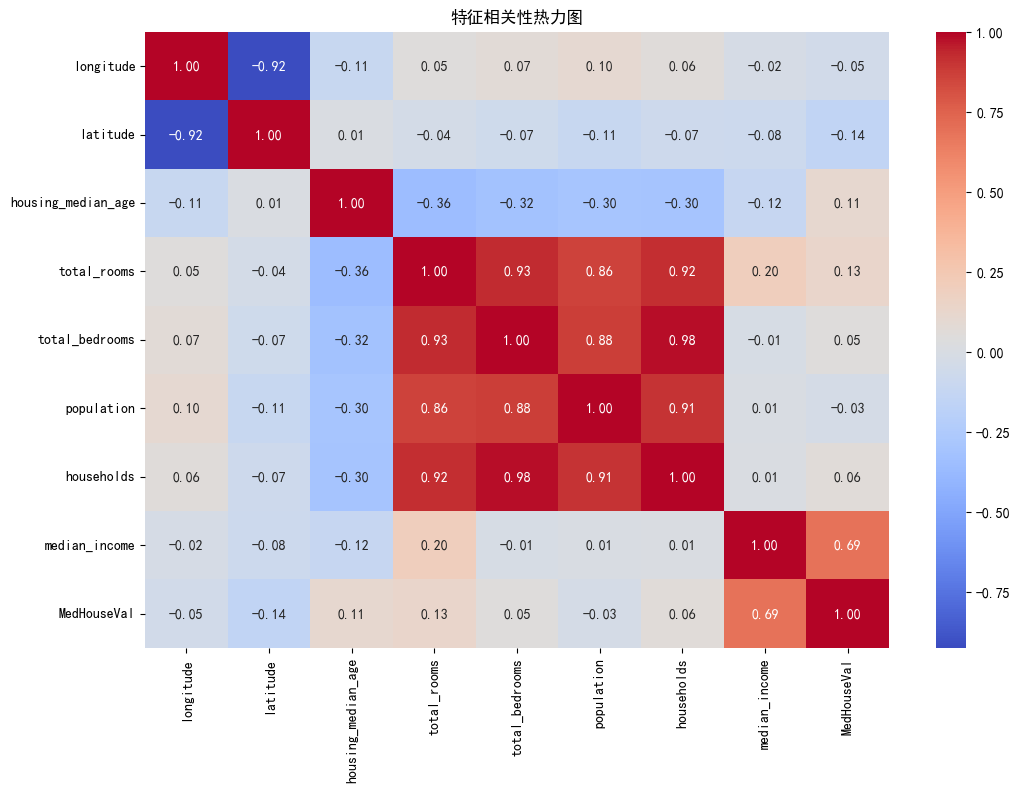

In [39]:
plt.figure(figsize=(12, 8))
# 绘制特征之间的相关性热力图
sns.heatmap(california_df.drop(['ocean_proximity'], axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('特征相关性热力图')
plt.show()

选择高相关特征，设置目标变量与输入变量

In [40]:
features = ['median_income', 'total_rooms', 'housing_median_age','total_bedrooms','population','households','latitude','longitude']  # 选取高相关的特征
X = california_df[features]  # 在数据集中选取特征（上一步中选的高相关的特征值）列作为自变量
y = california_df['MedHouseVal']  # 选取目标变量(房价)作为因变量

划分数据集

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

特征值标准化处理

In [42]:
scaler = StandardScaler()  # 创建标准化处理对象
X_train_scaled = scaler.fit_transform(X_train)  # 对自变量中的训练集进行标准化处理
X_test_scaled = scaler.transform(X_test)  # 对自变量中的测试集进行标准化处理(注意：这里使用的是transform而不是fit_transform，因为我们要使用训练集的均值和标准差来标准化测试集)

建立并训练多元线性回归模型

In [43]:
model = LinearRegression()  # 创建多元线性回归模型对象
model.fit(X_train_scaled, Y_train)  # 使用训练集数据拟合模型
predictions = model.predict(X_test_scaled)  # 使用测试集数据进行预测

模型预测与评估

In [44]:
mse = mean_squared_error(Y_test, predictions)  # 计算均方误差
rmse = np.sqrt(mse)  # 计算均方根误差
r2 = r2_score(Y_test, predictions)  # 计算R²分数

print(f'均方误差 (MSE): {mse:.4f}')
print(f'均方根误差 (RMSE): {rmse:.4f}')
print(f'R² 分数: {r2:.4f}')
print(f'模型系数: {model.coef_}')  #特征权重（斜率）
print(f'模型截距: {model.intercept_}')  #截距（偏置）

均方误差 (MSE): 4921881237.6281
均方根误差 (RMSE): 70156.1205
R² 分数: 0.6401
模型系数: [ 76467.23987025 -18174.25470158  14527.41138834  48354.30740632
 -41513.2259601   15739.49656088 -90434.67078093 -85341.725905  ]
模型截距: 206644.4000978828


预测结果与真实房价对比图

C:\Users\Zhang\AppData\Local\Temp\ipykernel_31876\1460127295.py:25: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
d:\modeling\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


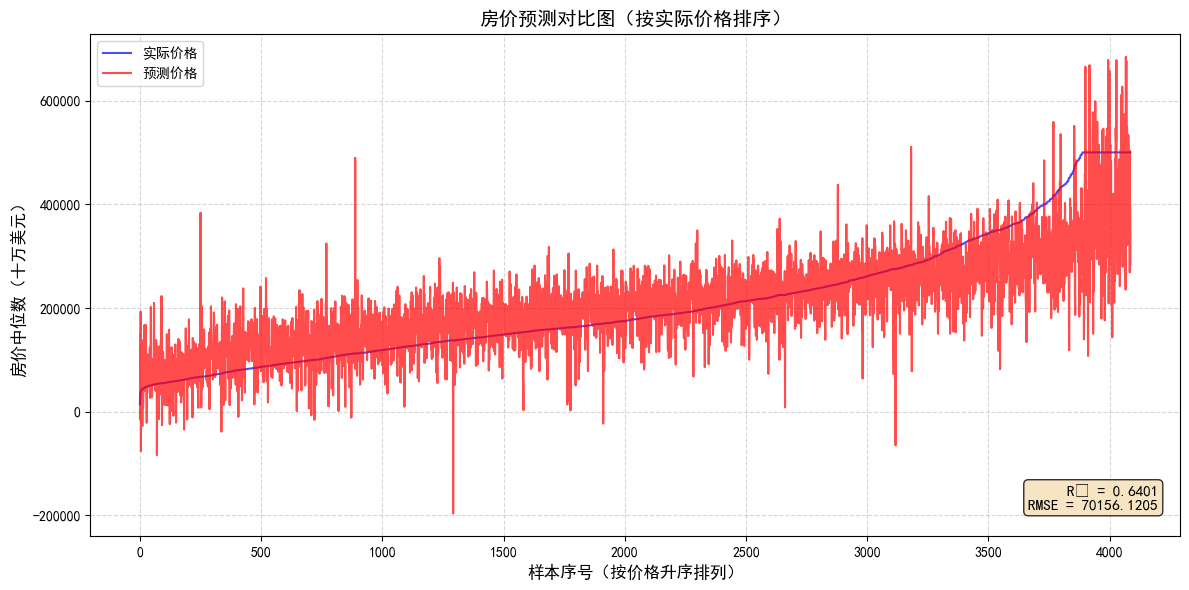

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


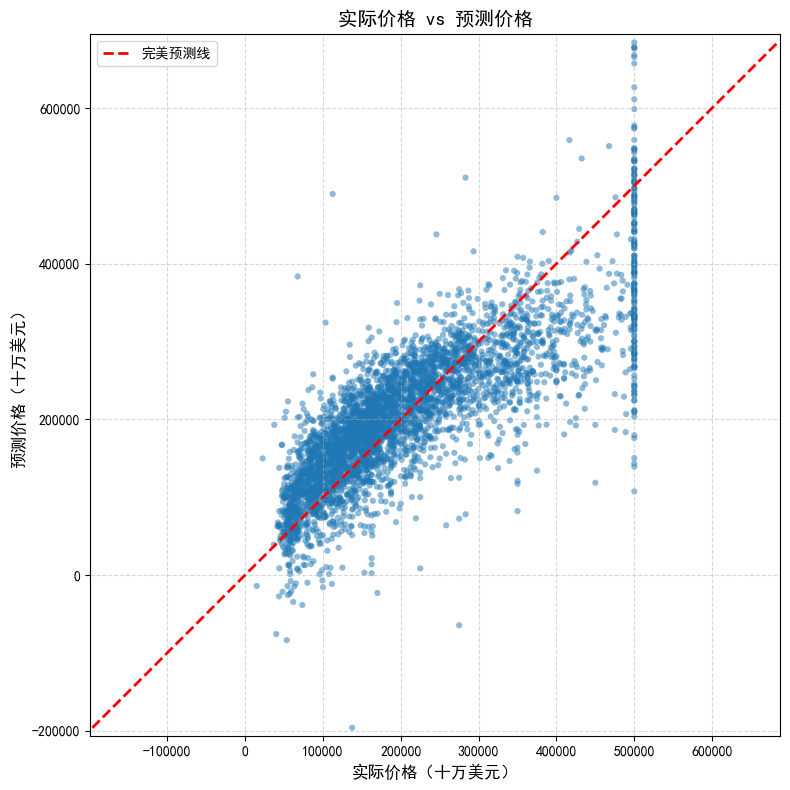

In [45]:
# 方案一：排序对比图
plt.figure(figsize=(12, 6))

sorted_indices = np.argsort(Y_test.values)  # 注意：Y_test是Series，用.values
Y_sorted = Y_test.values[sorted_indices]
pred_sorted = predictions[sorted_indices]

plt.plot(Y_sorted, label='实际价格', color='blue', alpha=0.7, linewidth=1.5)
plt.plot(pred_sorted, label='预测价格', color='red', alpha=0.7, linewidth=1.5)

plt.title("房价预测对比图（按实际价格排序）", fontsize=14)
plt.xlabel("样本序号（按价格升序排列）", fontsize=12)
plt.ylabel("房价中位数（十万美元）", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# 添加评估指标
r2 = r2_score(Y_test, predictions)
rmse = np.sqrt(mean_squared_error(Y_test, predictions))
plt.text(0.98, 0.05, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# 方案二：实际 vs 预测散点图
plt.figure(figsize=(8, 8))
plt.scatter(Y_test, predictions, alpha=0.5, edgecolors='none', s=20)

min_val = min(Y_test.min(), predictions.min())
max_val = max(Y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         'r--', lw=2, label='完美预测线')

plt.title("实际价格 vs 预测价格", fontsize=14)
plt.xlabel("实际价格（十万美元）", fontsize=12)
plt.ylabel("预测价格（十万美元）", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.tight_layout()
plt.show()